# 5.0 Model training - LightGBM - Optuna search


## Imports


In [1]:
import numpy as np
import pandas as pd
import joblib
import shap
import mlflow
import matplotlib.pyplot as plt
from optuna.importance import get_param_importances
from recruit_restaurant_visitor_forecasting.config.config import (
    MODELS_DIR,
    VISIT_DATE_COL,
    RANDOM_SEED,
    AIR_GENRE_COL,
    PROCESSED_DATA_DIR,
    VISITORS_COL
)
from recruit_restaurant_visitor_forecasting.config.features import CITY_COL, TOTAL_RES_COL, GOLDEN_WEEK_FLG
from recruit_restaurant_visitor_forecasting.config.preprocessing import DROP_COLUMNS, REMAINING_FEATURES
from recruit_restaurant_visitor_forecasting.config.modeling import (
    CV_SPLITS,
    TEST_SIZE,
    FIRST_ITER_TRIALS,
    SECOND_ITER_TRIALS,
    FS_VALID_SIZE,
    OBJECTIVE_FUNCTION
)
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    shap_fs,
    lgbm_optuna_search,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import (
    plot_actual_pred,
    plot_daily_error_overall,
    plot_daily_error_by_group,
    plot_error_mean_std,
    plot_error_radar,
    plot_errors_boxplot
)
from recruit_restaurant_visitor_forecasting.utils import (
    merge_daily_pred,
    get_format,
    optuna_cv_results_to_df,
    get_daily_error_stats_table,
    MEAN_ERROR,
    STD_ERROR,
    MIN_ABS_ERROR,
    MAX_POS_ERROR,
    MAX_NEG_ERROR,
    get_metrics,
    get_features_difference,
    rmsle
)
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict
from recruit_restaurant_visitor_forecasting.config.feature_names import agg_exp_col
from recruit_restaurant_visitor_forecasting.eda import print_best_params

2026-05-15 15:47:30.975 | INFO     | recruit_restaurant_visitor_forecasting.config.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [7]:
MODEL_NAME = "lgbm_40it_nofill_gap"
MODEL_PATH = MODELS_DIR / f"{MODEL_NAME}_model.pkl"
MLFLOW_WORK = True

if MLFLOW_WORK:
    mlflow.set_experiment(f"recruit_restaurant_visitors_v05")

## Load and prepare

In [3]:
features, labels = load_data()
features = prepare_features(features)
labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [4]:
X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-03-08 00:00:00
Test set dates: 2017-03-09 00:00:00 to 2017-04-22 00:00:00


In [5]:
DROP_COLUMNS = features.columns.difference(REMAINING_FEATURES).to_list()

## Training

### Iteration 1

In [6]:
study, model = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=8,
    drop_features=DROP_COLUMNS,
    n_trials=FIRST_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    window_test_size=39,
    mlflow_run_name="study_first_iter",
    objective_func=OBJECTIVE_FUNCTION,
)
print_best_params(study)

[I 2026-05-15 15:48:17,426] A new study created in memory with name: no-name-49e2e102-a964-4b7e-996b-9b11446ce384
[I 2026-05-15 15:52:13,159] Trial 0 finished with value: 0.9696160157518399 and parameters: {'model__max_depth': 3, 'model__learning_rate': 0.25923329500434156, 'model__n_estimators': 995, 'model__subsample': 0.7862915633430194, 'model__colsample_bytree': 0.7017918907432026, 'model__min_child_samples': 33, 'model__reg_alpha': 0.012897262748416584, 'model__reg_lambda': 0.826354423863233, 'model__num_leaves': 4}. Best is trial 0 with value: 0.9696160157518399.
[I 2026-05-15 15:53:29,874] Trial 2 finished with value: 1.1108445193689263 and parameters: {'model__max_depth': 3, 'model__learning_rate': 0.012499395274614434, 'model__n_estimators': 181, 'model__subsample': 0.7162966514687741, 'model__colsample_bytree': 0.826300167031923, 'model__min_child_samples': 28, 'model__reg_alpha': 0.08062757133953999, 'model__reg_lambda': 0.00014181277276772877, 'model__num_leaves': 6}. Best

Best parameters: {'model__max_depth': 5, 'model__learning_rate': 0.017269205884403234, 'model__n_estimators': 599, 'model__subsample': 0.757576540071614, 'model__colsample_bytree': 0.8574599630236199, 'model__min_child_samples': 16, 'model__reg_alpha': 0.002734308898503685, 'model__reg_lambda': 0.0003057969176333265, 'model__num_leaves': 32}
Best score: 0.94919


In [58]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
37,"{'model__max_depth': 5, 'model__learning_rate'...",0.146821,0.949195,0.904800,0.887790,0.847060,1.240233,0.866089,1
26,"{'model__max_depth': 5, 'model__learning_rate'...",0.145807,0.952272,0.914890,0.889731,0.846585,1.240392,0.869764,2
27,"{'model__max_depth': 5, 'model__learning_rate'...",0.146263,0.952381,0.914442,0.887570,0.849508,1.241742,0.868643,3
39,"{'model__max_depth': 5, 'model__learning_rate'...",0.145732,0.952505,0.908436,0.891473,0.848091,1.241207,0.873318,4
38,"{'model__max_depth': 5, 'model__learning_rate'...",0.144508,0.952506,0.913274,0.889208,0.849606,1.238494,0.871946,5


### SHAP feature selection

In [28]:
selected_features, feature_stats = shap_fs(
    X_train,
    y_train,
    model.named_steps["model"],
    drop_features=DROP_COLUMNS,
    test_size=FS_VALID_SIZE,
)

### Iteration 2

In [29]:
study, model_shap = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=8,
    drop_features=DROP_COLUMNS,
    n_trials=SECOND_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    features_top=selected_features,
    window_test_size=39,
    mlflow_run_name="study_second_iter",
    objective_func=OBJECTIVE_FUNCTION,
)
print_best_params(study)

[I 2026-05-07 11:04:44,466] A new study created in memory with name: no-name-2a6c7a08-5dd6-4592-a336-e54a46d0334d
[I 2026-05-07 11:06:02,546] Trial 4 finished with value: 1.250386394549386 and parameters: {'model__max_depth': 4, 'model__learning_rate': 0.012183065921938869, 'model__n_estimators': 717, 'model__subsample': 0.907770326921071, 'model__colsample_bytree': 0.9788021436257383, 'model__min_child_samples': 14, 'model__reg_alpha': 2.589069726453133, 'model__reg_lambda': 0.735241599621052, 'model__num_leaves': 13, 'feature_dropper__keep_count': 10}. Best is trial 4 with value: 1.250386394549386.
[I 2026-05-07 11:07:28,557] Trial 0 finished with value: 0.9066033227505665 and parameters: {'model__max_depth': 3, 'model__learning_rate': 0.027652227750141114, 'model__n_estimators': 975, 'model__subsample': 0.5433537932034416, 'model__colsample_bytree': 0.9859131071565514, 'model__min_child_samples': 17, 'model__reg_alpha': 0.00010272178611137563, 'model__reg_lambda': 0.0189252160098944

Best parameters: {'model__max_depth': 5, 'model__learning_rate': 0.28403355851083156, 'model__n_estimators': 967, 'model__subsample': 0.7637097468028359, 'model__colsample_bytree': 0.7021666378958341, 'model__min_child_samples': 26, 'model__reg_alpha': 0.0008559416164552018, 'model__reg_lambda': 5.606192888705427, 'model__num_leaves': 25, 'feature_dropper__keep_count': 23}
Best score: 0.84864


In [30]:
cv_results = optuna_cv_results_to_df(study)
cv_results.sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
169,"{'model__max_depth': 5, 'model__learning_rate'...",0.140528,0.848641,0.823056,0.797595,0.751179,1.123872,0.747504,1
170,"{'model__max_depth': 5, 'model__learning_rate'...",0.141721,0.848965,0.822557,0.797400,0.749813,1.126671,0.748384,2
167,"{'model__max_depth': 5, 'model__learning_rate'...",0.142150,0.849163,0.824391,0.798018,0.748662,1.127296,0.747450,3
172,"{'model__max_depth': 5, 'model__learning_rate'...",0.141864,0.849411,0.825742,0.797721,0.750284,1.126847,0.746464,4
191,"{'model__max_depth': 5, 'model__learning_rate'...",0.143247,0.849467,0.826747,0.798146,0.749111,1.129241,0.744092,5


### Scores

In [10]:
y_train_pred = model_shap.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

print("Train set")
get_metrics(y_train, y_train_pred)

Train set


RMSLE      0.866206
MAE        6.791967
MSE      111.041710
dtype: float64

In [11]:
y_test_pred, temp_features = recursive_predict(
    model_shap, X_test, X_train, y_train, update_reservations=False
)

Predicting recursively: 100%|██████████| 45/45 [01:14<00:00,  1.65s/it]


In [13]:
test_rmsle = rmsle(y_test, y_test_pred)
print("Test set")
get_metrics(y_test, y_test_pred)

Test set


RMSLE      0.918655
MAE        7.928130
MSE      160.960475
dtype: float64

## Graphs

### Optuna importances

In [14]:
get_param_importances(study)

{'model__n_estimators': np.float64(0.8861723274048096),
 'model__learning_rate': np.float64(0.05573067434796687),
 'model__max_depth': np.float64(0.036539359180611644),
 'model__min_child_samples': np.float64(0.008002482240223327),
 'model__subsample': np.float64(0.006847453023811735),
 'model__colsample_bytree': np.float64(0.00466055705366801),
 'model__reg_alpha': np.float64(0.0014047699660848427),
 'model__reg_lambda': np.float64(0.0006423767828239784)}

### SHAP explanation

In [15]:
X_test_clean = model_shap.named_steps["feature_dropper"].transform(X_test)
lgbm = model_shap.named_steps["model"]

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_test_clean)

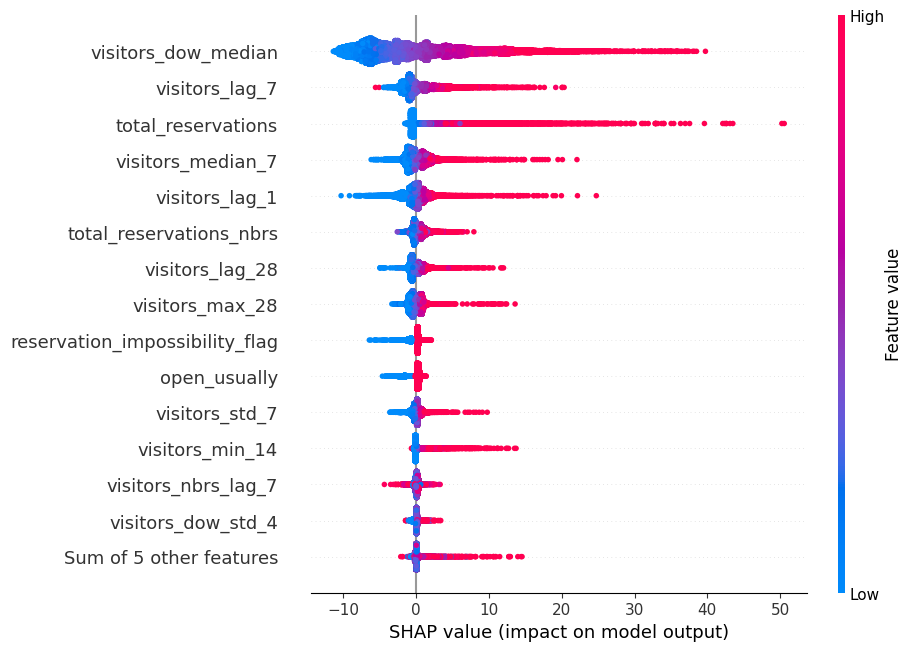

In [16]:
shap.plots.beeswarm(shap_values, max_display=15)

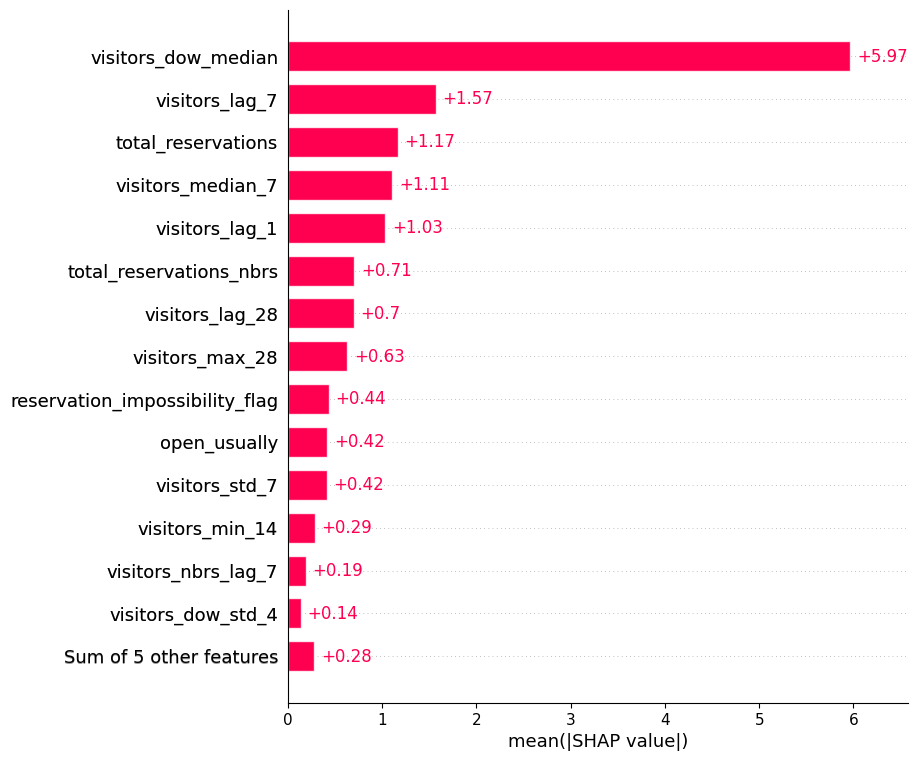

In [17]:
shap.plots.bar(shap_values, max_display=15)

### Golden week prediction

In [18]:
gw_mask = X_train[GOLDEN_WEEK_FLG] == 1
X_gw = X_train[gw_mask]
y_gw = y_train[gw_mask]
before_gw_mask = X_train[VISIT_DATE_COL] < X_gw[VISIT_DATE_COL].min()
X_before_gw = X_train[before_gw_mask]
y_before_gw = y_train[before_gw_mask]

In [19]:
y_test_gw, _ = recursive_predict(
    model_shap,
    X_gw,
    X_before_gw,
    y_before_gw,
    drop_cols=DROP_COLUMNS,
    update_reservations=False
)

Predicting recursively: 100%|██████████| 7/7 [00:04<00:00,  1.40it/s]


In [20]:
print("Golden week")
get_metrics(y_gw, y_test_gw)

Golden week


RMSLE      1.307987
MAE       12.468028
MSE      363.989494
dtype: float64

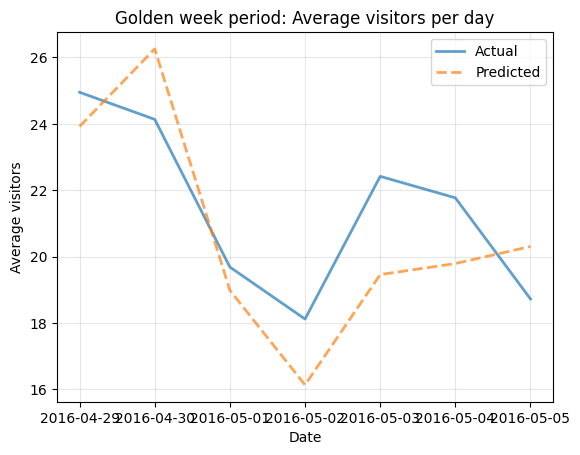

In [21]:
daily = merge_daily_pred(X_gw[VISIT_DATE_COL], y_gw, y_test_gw)
fig, axes = plt.subplots()
plot_actual_pred(axes, daily, "Golden week period")
plt.show()

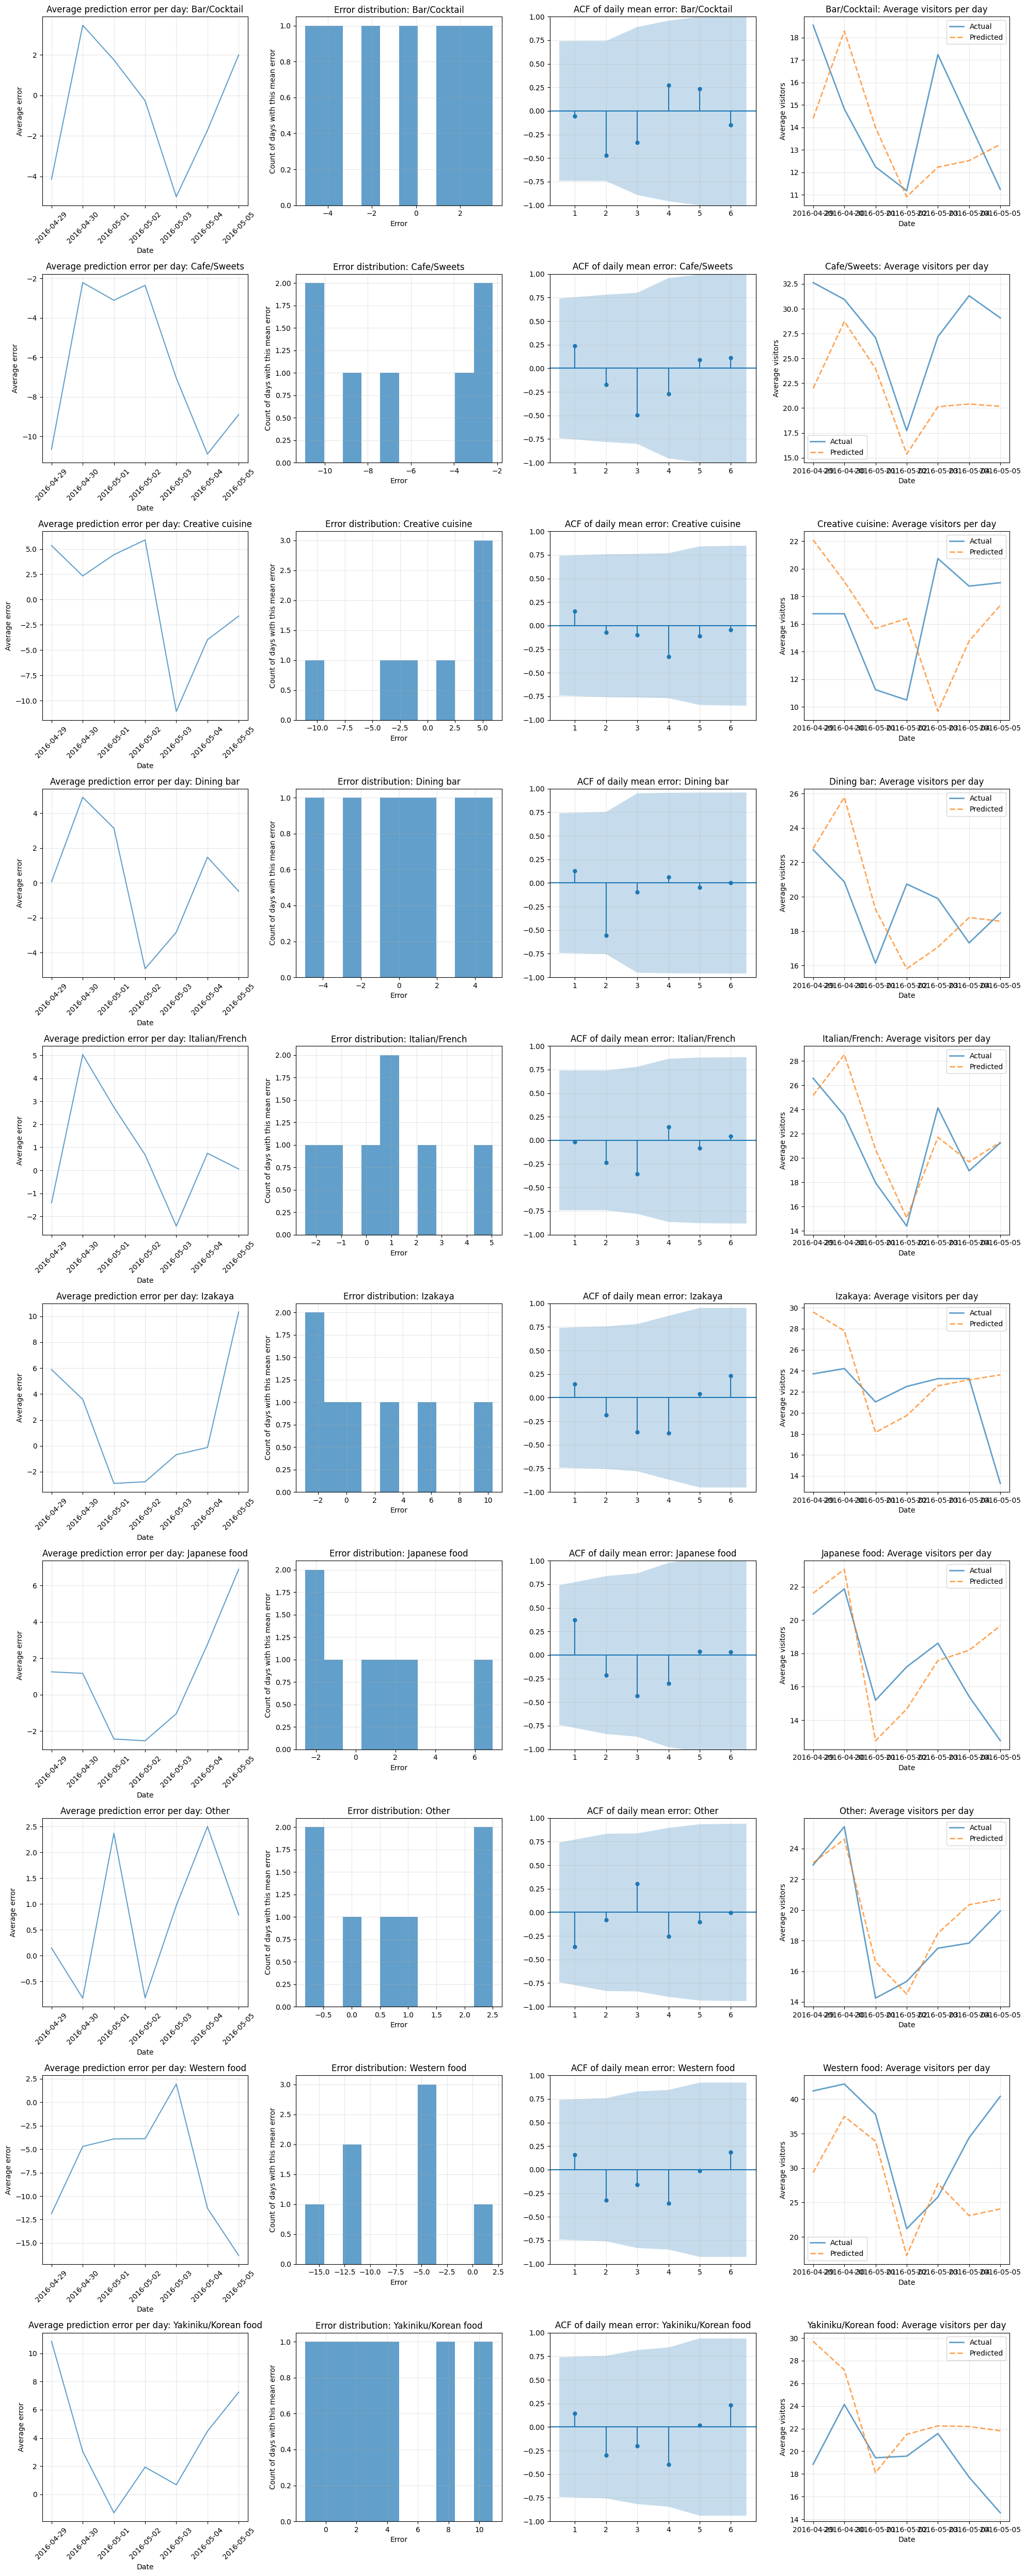

In [22]:
plot_daily_error_by_group(X_gw, y_gw, y_test_gw, AIR_GENRE_COL)

A significantly large average error is observed compared to the average error for the entire dataset. The largest difference between predicted and actual numbers is observed on Tuesdays and Wednesdays, the 3rd and 4th. These days typically have fewer visitors, leading the model to predict significantly fewer visitors than the actual number.

The situation is similar across genres: the final days are underpredicted across all genres.

### Visitors per day: actual vs predicted

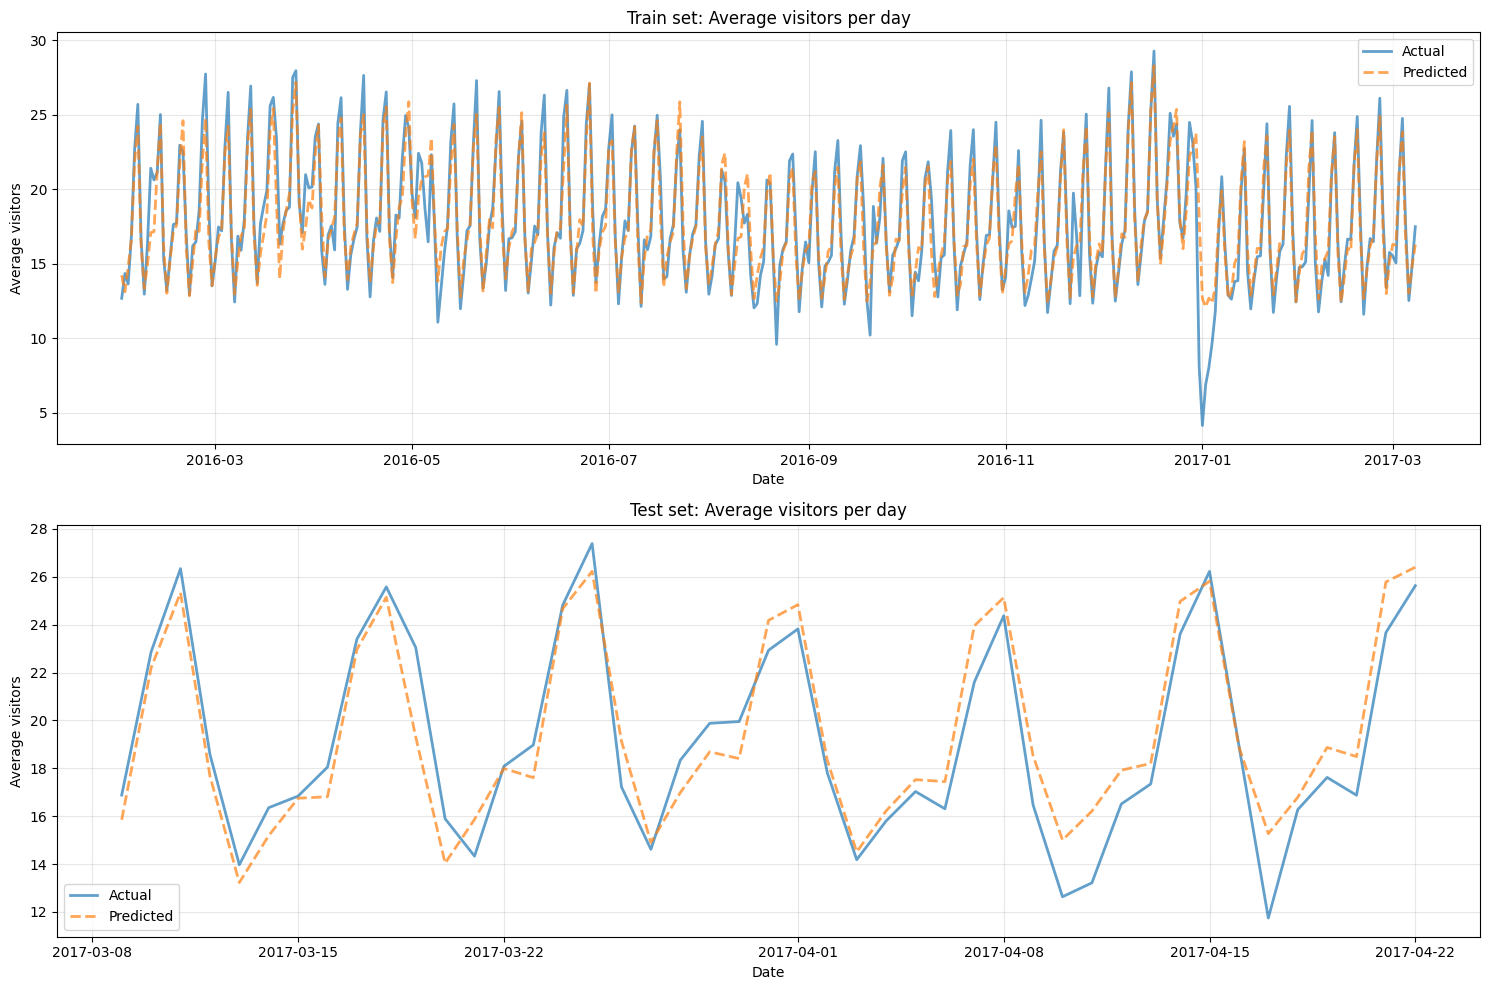

In [23]:
y_train_pred = pd.Series(y_train_pred, name="predicted")
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_actual_pred(axes[0], train_daily, "Train set")
plot_actual_pred(axes[1], test_daily, "Test set")

plt.tight_layout()
plt.show()

### Residuals

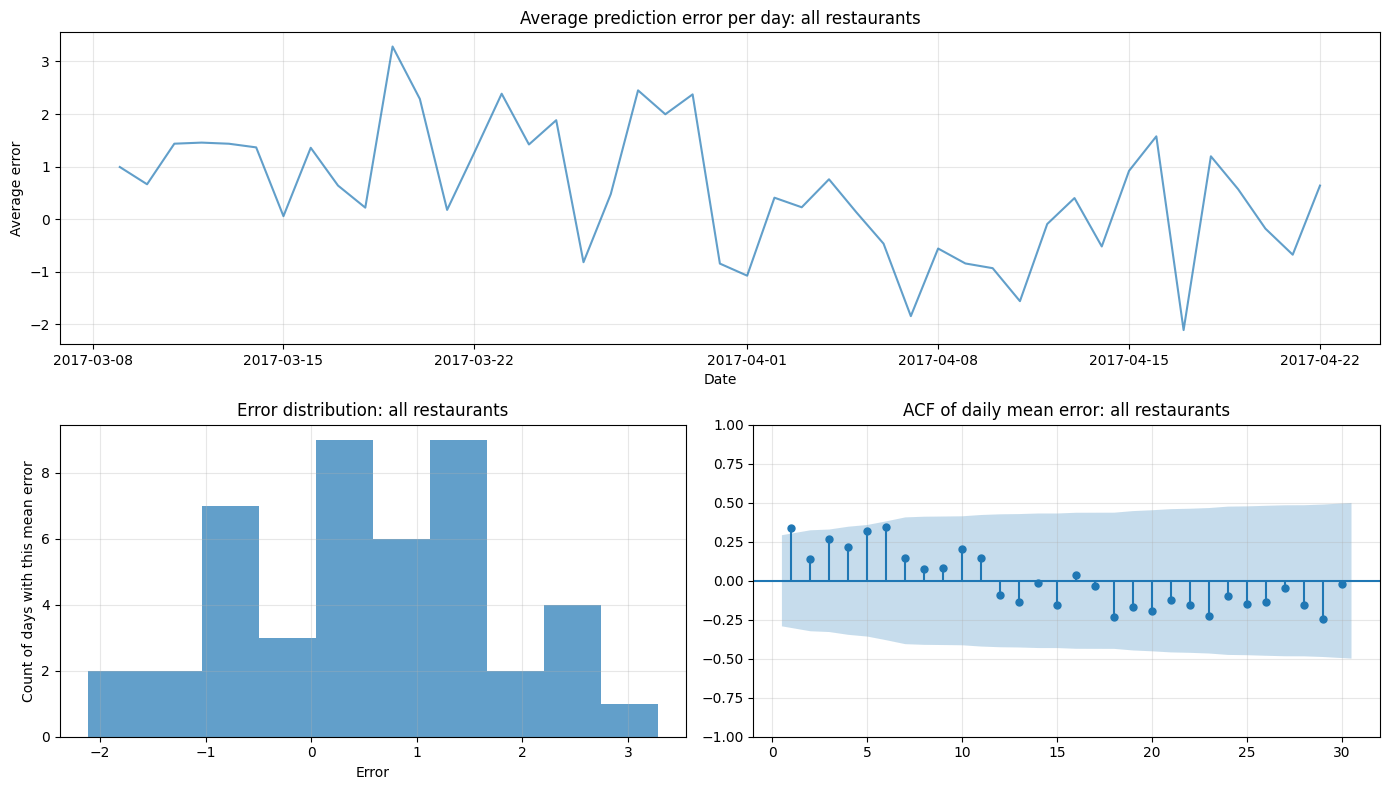

In [38]:
plot_daily_error_overall(X_test, y_test_pred, y_test)

The residuals have some seasonality, so it is likely that some dependence is not taken into account.

#### Cities

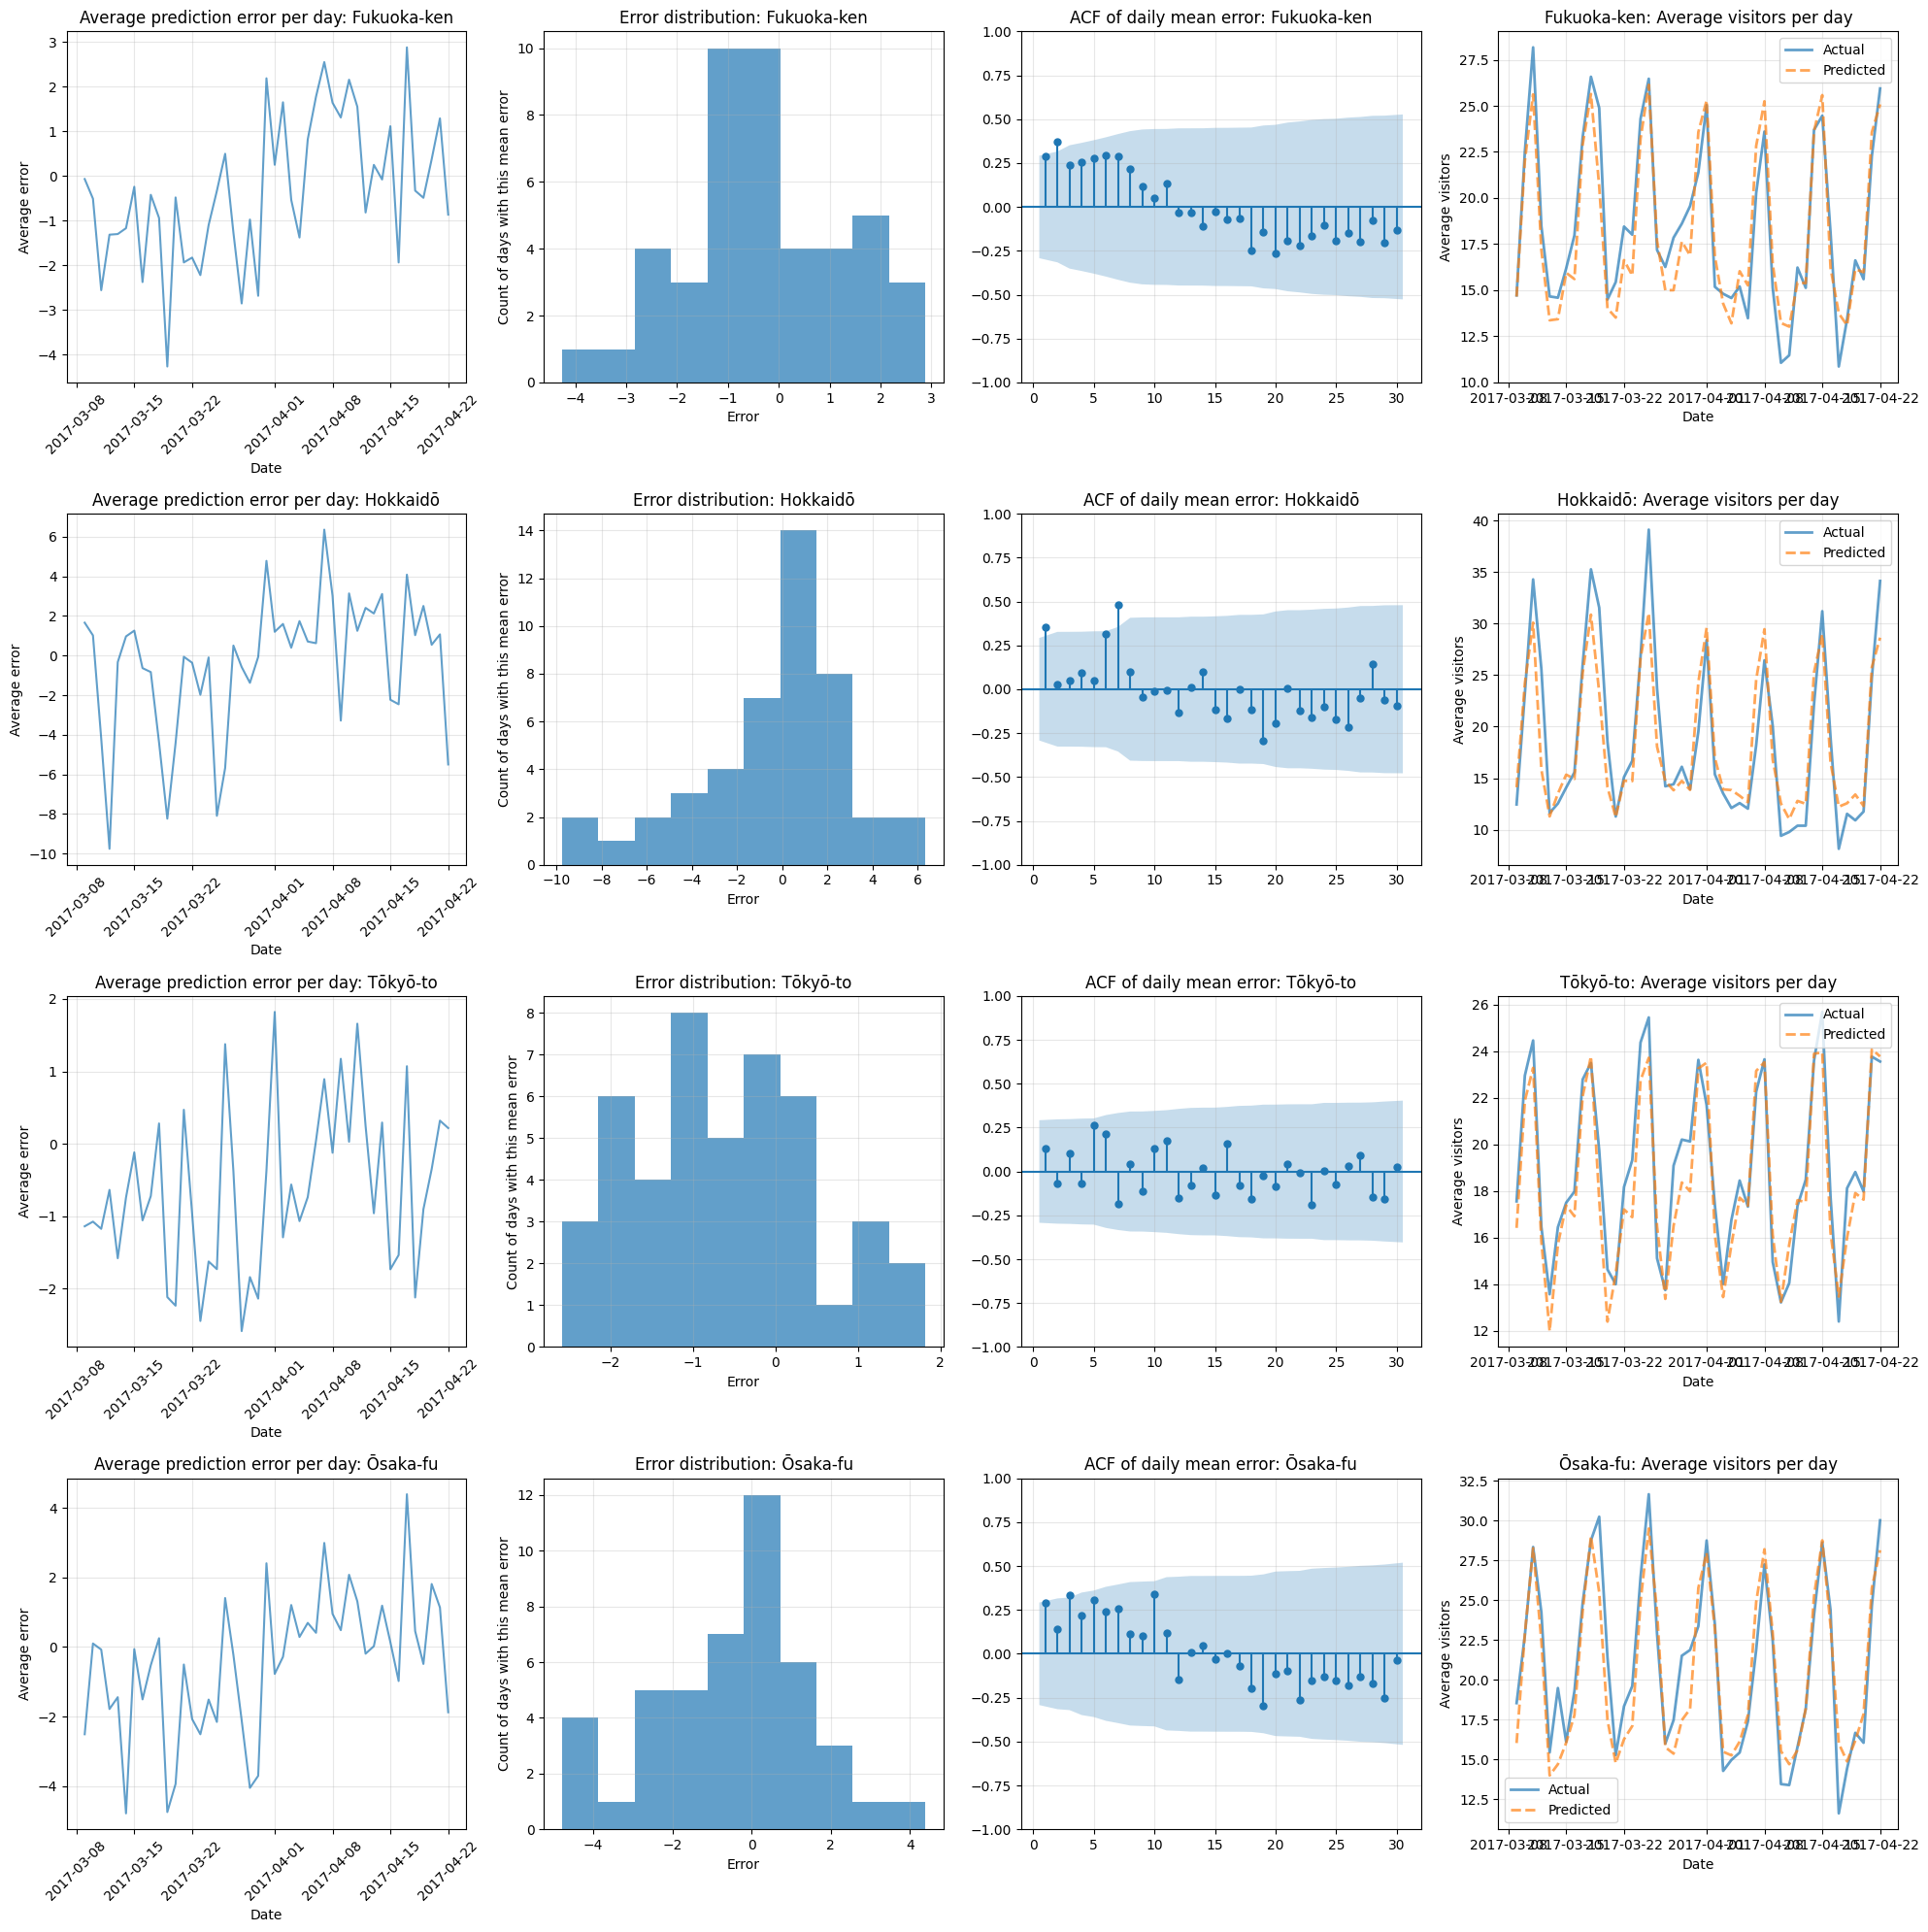

In [39]:
plot_daily_error_by_group(X_test, y_test, y_test_pred, CITY_COL)

The residuals averaged across cities don't differ significantly from each other on average. For most of them, the mean error increases between 2017-03 and 2017-04, but in some cities it's larger, and in others, smaller.

In [42]:
city_group_error_info = get_daily_error_stats_table(X_test, y_test, y_test_pred, CITY_COL)
city_group_error_info

,city,mean_error,std_error,min_abs_error,max_pos_error,max_neg_error,acf_1,acf_2,acf_3,acf_4,acf_5,acf_6,acf_7,acf_8,acf_9,acf_10,acf_11,acf_12,acf_13,acf_14
0,Fukuoka-ken,-0.328,1.594,0.064,2.885,4.262,0.290,0.378,0.250,0.270,0.291,0.334,0.327,0.265,0.149,0.073,0.194,-0.016,0.000,-0.093
1,Hokkaidō,-0.389,3.417,0.062,6.357,9.759,0.366,0.028,0.051,0.112,0.060,0.380,0.585,0.123,-0.052,-0.008,0.007,-0.173,0.054,0.183
2,Tōkyō-to,-0.626,1.124,0.029,1.821,2.587,0.133,-0.066,0.105,-0.066,0.278,0.234,-0.199,0.047,-0.126,0.147,0.208,-0.184,-0.093,0.046
3,Ōsaka-fu,-0.469,1.992,0.022,4.392,4.784,0.293,0.146,0.347,0.229,0.324,0.308,0.322,0.155,0.143,0.441,0.187,-0.167,0.079,0.154


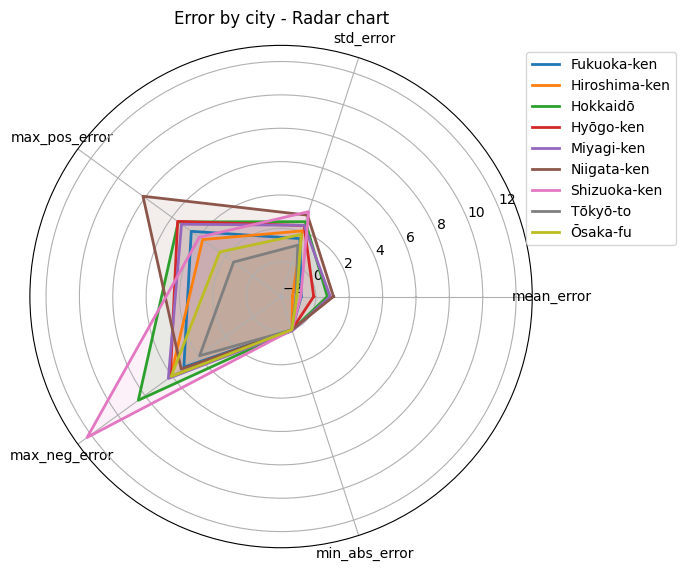

In [13]:
categories = [
    MEAN_ERROR,
    STD_ERROR,
    MAX_POS_ERROR,
    MAX_NEG_ERROR,
    MIN_ABS_ERROR
]
plot_error_radar(city_group_error_info, CITY_COL, categories, False)

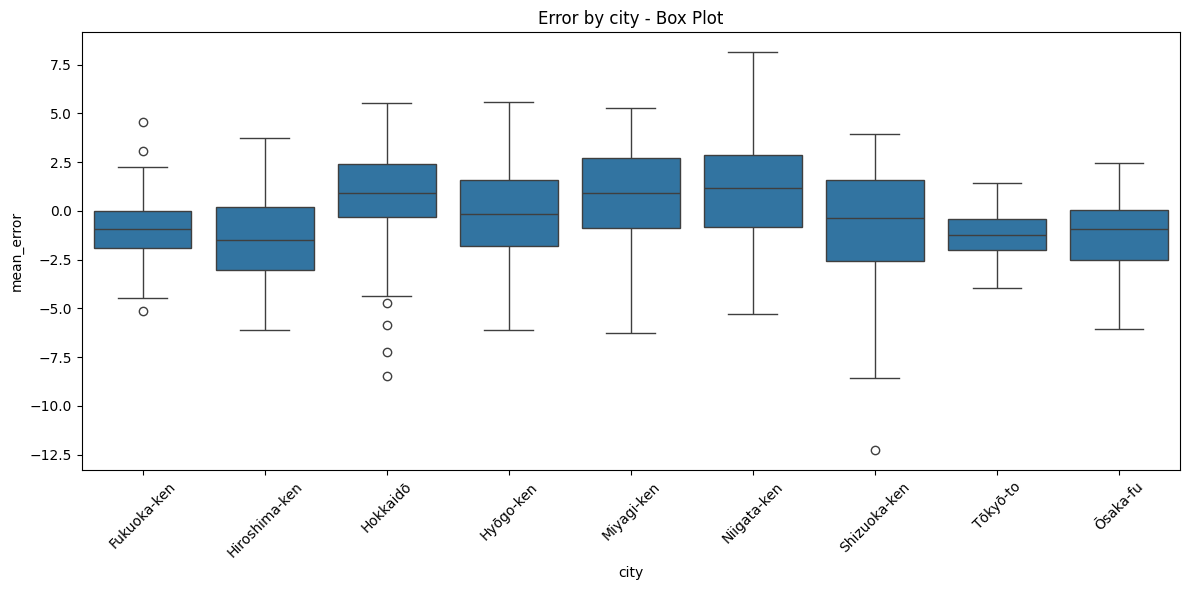

In [14]:
plot_errors_boxplot(X_test, y_test, y_test_pred, CITY_COL)

#### Genres

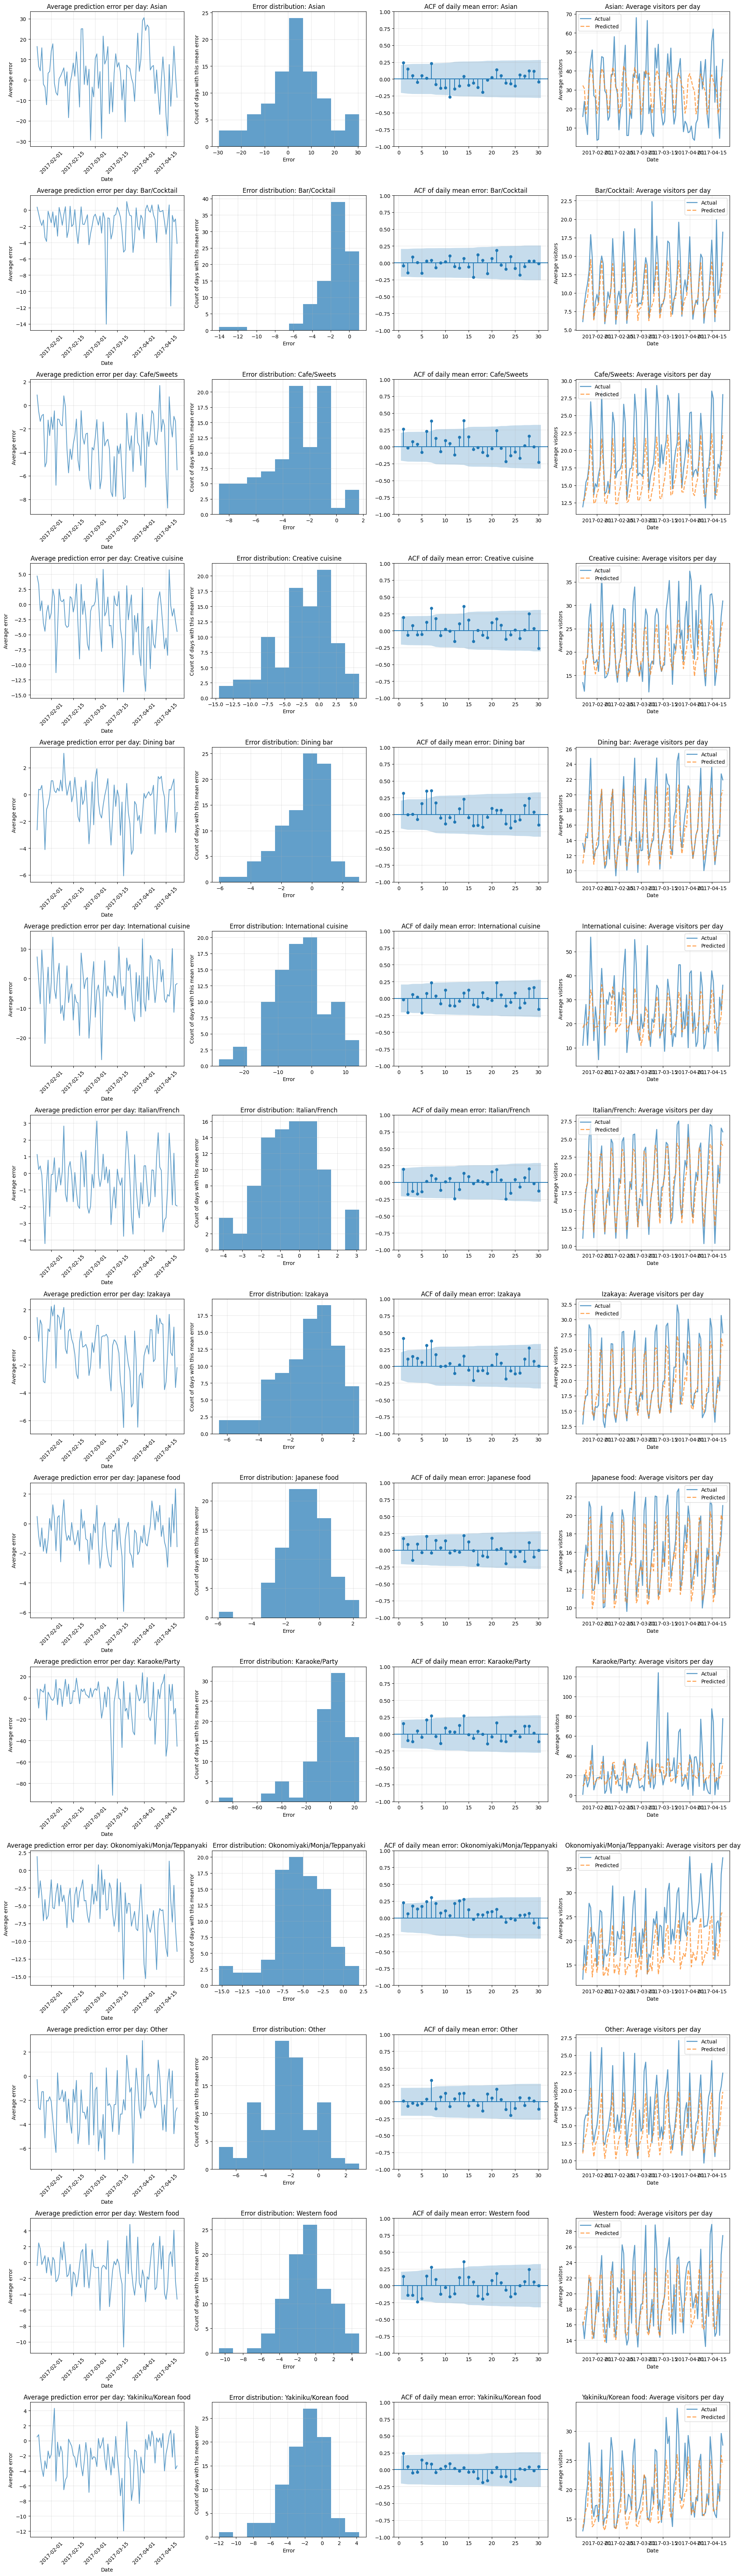

In [27]:
plot_daily_error_by_group(X_test, y_test, y_test_pred, AIR_GENRE_COL)

The largest residuals are observed for restaurants with the Asian and Karaoke/Party genres. However, firstly, the model doesn't consider the genre_te parameter. And if we recall the previous analysis, we see that there are fewer than five restaurants for each of these genres. Creating a different model for them is a questionable idea, but we can try removing the genre with some threshold and retraining the model.

In [15]:
genre_group_error_info = get_daily_error_stats_table(X_test, y_test, y_test_pred, AIR_GENRE_COL)
genre_group_error_info

,air_genre_name,mean_error,std_error,min_abs_error,max_pos_error,max_neg_error,acf_1,acf_2,acf_3,acf_4,acf_5,acf_6,acf_7,acf_8,acf_9,acf_10,acf_11,acf_12,acf_13,acf_14
0,Asian,3.615,11.989,0.091,35.396,25.671,0.253,0.211,0.119,0.022,0.119,-0.023,0.175,-0.113,-0.139,-0.117,-0.229,-0.095,-0.111,-0.026
1,Bar/Cocktail,-0.640,2.164,0.007,2.965,13.160,-0.069,-0.090,0.123,0.041,-0.109,0.018,-0.056,-0.134,0.023,0.008,0.072,-0.078,-0.102,0.058
2,Cafe/Sweets,-2.222,2.097,0.044,2.895,7.370,0.283,0.111,0.227,0.175,-0.010,0.146,0.309,0.095,-0.000,0.270,0.212,-0.059,0.128,0.363
3,Creative cuisine,-1.714,3.740,0.003,5.947,12.101,0.106,-0.033,0.227,0.038,-0.024,0.018,0.256,0.149,-0.083,0.110,0.060,-0.182,0.009,0.229
4,Dining bar,0.074,1.321,0.006,3.722,3.696,0.268,0.118,0.144,0.003,0.217,0.288,0.214,-0.005,-0.050,-0.070,0.026,-0.102,-0.082,0.041
5,International cuisine,-2.390,7.684,0.021,14.589,26.388,-0.021,-0.144,0.151,0.121,-0.165,0.055,0.236,0.042,-0.072,0.172,-0.048,-0.057,-0.089,0.080
6,Italian/French,-0.011,1.429,0.008,2.892,3.547,0.240,-0.047,-0.135,-0.183,-0.164,-0.054,0.049,-0.025,-0.138,0.005,0.077,-0.279,-0.129,0.115
7,Izakaya,-0.457,1.581,0.033,3.239,6.605,0.426,0.277,0.284,0.250,0.221,0.308,0.253,0.035,0.018,0.027,0.080,-0.100,-0.115,-0.068
8,Japanese food,-0.340,1.180,0.021,3.342,2.505,0.183,0.191,-0.116,0.184,0.038,0.215,-0.127,0.103,-0.069,0.184,-0.049,0.111,0.042,0.181
9,Karaoke/Party,-0.514,17.904,0.263,34.971,77.414,0.176,-0.074,-0.112,0.093,0.016,0.067,0.094,-0.123,-0.084,0.173,0.100,0.112,0.162,0.280


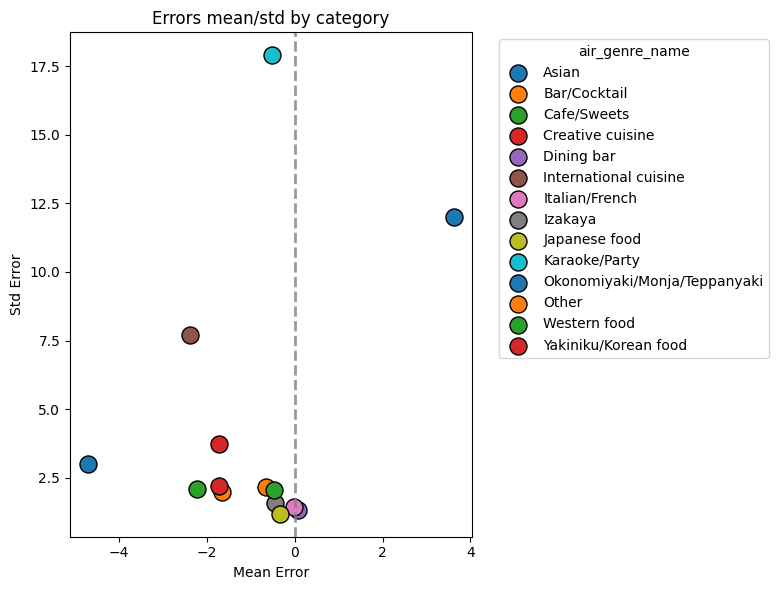

In [16]:
plot_error_mean_std(genre_group_error_info, AIR_GENRE_COL)

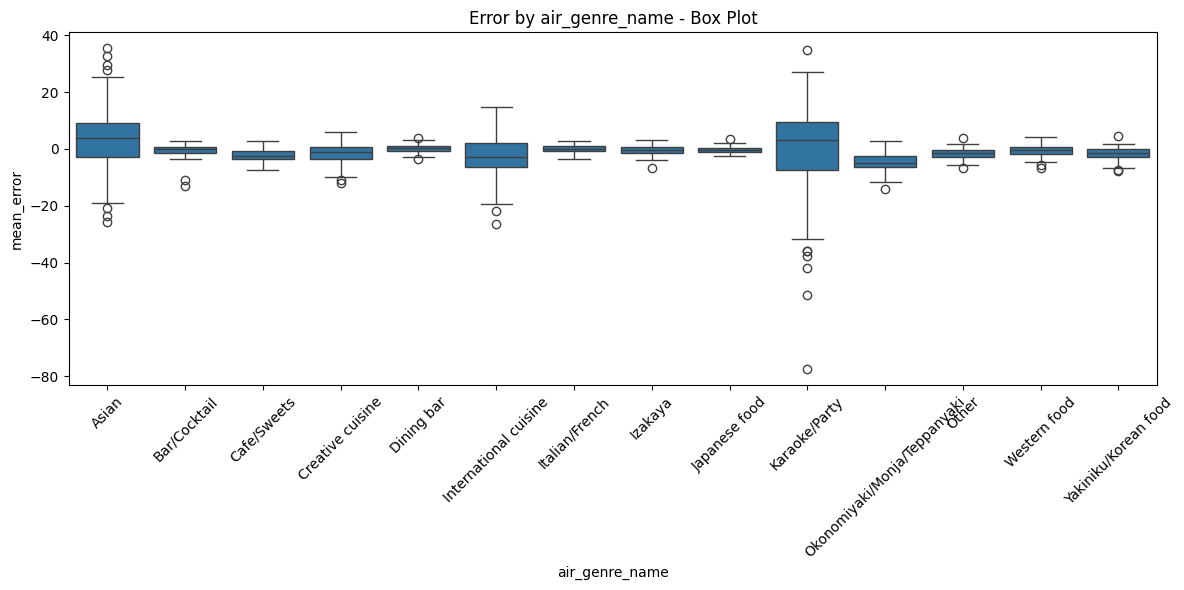

In [17]:
plot_errors_boxplot(X_test, y_test, y_test_pred, AIR_GENRE_COL)

### Overpredictions / underpredictions

In [24]:
res_df = pd.DataFrame({"actual": y_test, "residual": y_test - y_test_pred})
res_df.corr()

,actual,residual
actual,1.000000,0.649953
residual,0.649953,1.000000


[]

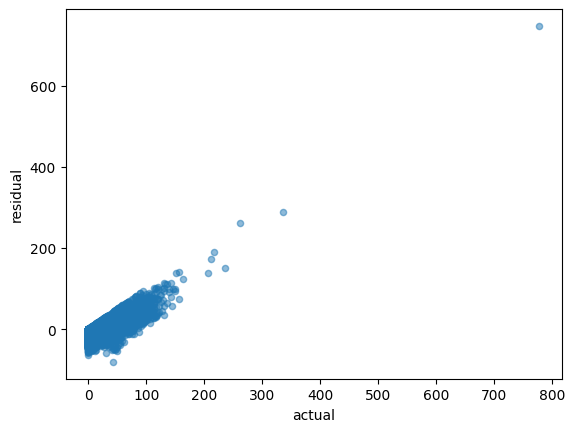

In [25]:
res_df.plot.scatter(x="actual", y="residual", alpha=0.5)
plt.plot()

In [26]:
X_train_clean = model_shap.named_steps["feature_dropper"].transform(X_train)
y_train_90q = y_train[y_train > y_train.quantile(0.9)]
X_train_90q = X_train_clean.iloc[y_train_90q.index]

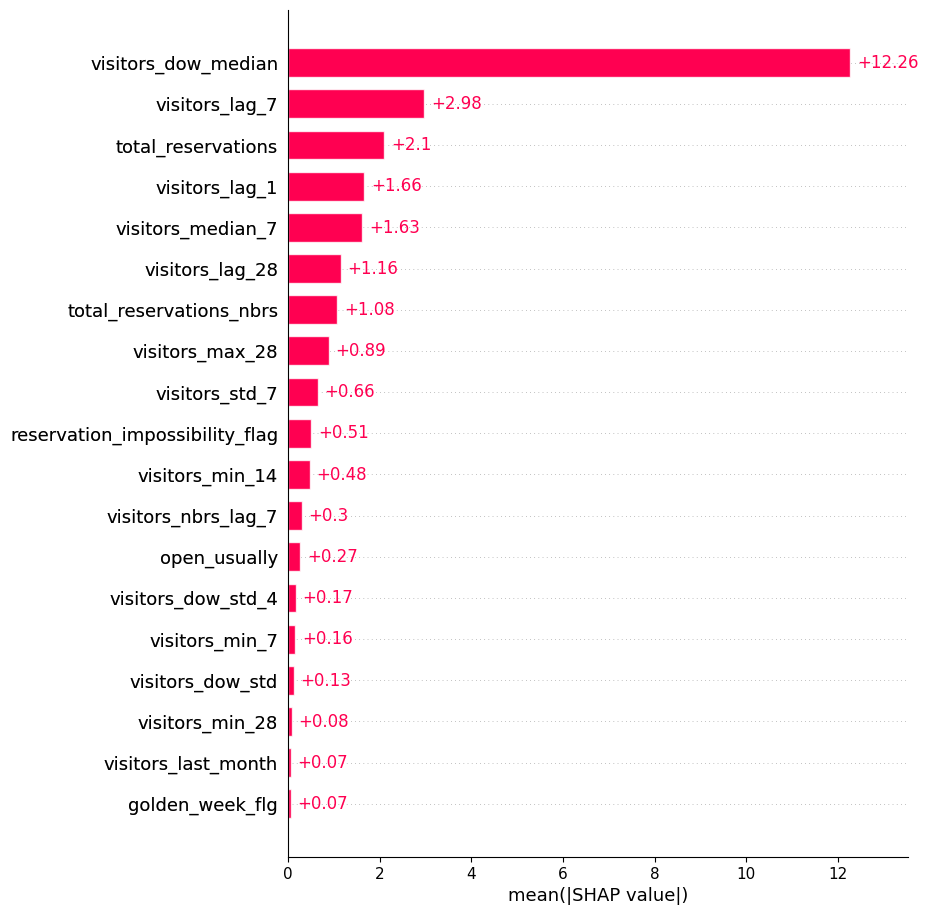

In [27]:
shap_many_visitors = explainer(X_train_90q)
shap.plots.bar(shap_many_visitors, max_display=24)

In [28]:
X_y = X_train.merge(y_train.rename(VISITORS_COL), left_index=True, right_index=True)
X_y = X_y.merge(y_train_pred, left_index=True, right_index=True)
q90 = X_y[VISITORS_COL].quantile(0.9)

X_q90 = X_y[X_y[VISITORS_COL] >= q90]
X_less_q90 = X_y[X_y[VISITORS_COL] < q90]

In [29]:
numeric_cols = X_train_clean.select_dtypes(include='number').columns.to_list()
numeric_cols += ["predicted"]
get_features_difference(X_q90, X_less_q90, 7, numeric_cols)

,air_store_id,visit_date,visitors,visitors_prev,golden_week_flg_diff,open_usually_diff,reservation_impossibility_flag_diff,total_reservations_diff,total_reservations_nbrs_diff,visitors_median_7_diff,...,visitors_min_28_diff,visitors_lag_1_diff,visitors_lag_7_diff,visitors_lag_28_diff,visitors_nbrs_lag_7_diff,visitors_last_month_diff,visitors_dow_median_diff,visitors_dow_std_diff,visitors_dow_std_4_diff,predicted_diff
6243,air_b1bb1fae86617d7a,2016-10-22,52,33,0.0,0.0,0.0,0.0,0.560238,0.0,...,0.0,17.0,-7.0,10.0,4.411765,-45.0,-2.0,-0.382131,0.125803,0.362600
1351,air_e57dd6884595f60d,2016-04-27,52,35,0.0,0.0,0.0,0.0,7.947840,-12.0,...,0.0,0.0,-7.0,-2.0,0.201913,9.0,-0.5,-0.204327,-0.311808,-1.234833
10417,air_4cca5666eaf5c709,2017-01-27,40,34,0.0,0.0,0.0,0.0,-0.559397,-4.0,...,0.0,-12.0,-5.0,-4.0,-0.527659,-8.0,0.0,-0.084718,-1.796454,-3.872606
3752,air_c9ed65554b6edffb,2016-08-20,41,18,0.0,0.0,0.0,0.0,1.135526,-9.0,...,0.0,-8.0,8.0,30.0,-1.112805,-1.0,0.0,-0.088790,-0.694467,-0.380159
304,air_9b13c7feb0a0c431,2016-02-28,44,0,0.0,0.0,0.0,0.0,-13.130056,-26.0,...,0.0,8.0,-28.0,1.0,2.511628,3.0,-1.0,8.187033,13.087872,-3.663311
1623,air_c225148c0fcc5c72,2016-05-05,58,8,1.0,0.0,0.0,0.0,-9.116642,29.0,...,0.0,59.0,-3.0,-6.0,7.545213,-4.0,0.0,-0.209906,0.000000,17.083439
5682,air_3c05c8f26c611eb9,2016-10-09,50,18,0.0,0.0,0.0,0.0,1.038563,-10.0,...,0.0,-8.0,-7.0,-2.0,-2.101562,6.0,-0.5,-0.113952,0.143131,-2.652587
4693,air_32460819c7600037,2016-09-15,57,33,0.0,0.0,0.0,0.0,-0.547389,7.0,...,0.0,19.0,-18.0,-4.0,0.094364,4.0,0.0,-0.147815,-0.635703,-1.222152
11578,air_4043b7ccfbffa732,2017-02-26,87,24,0.0,0.0,0.0,0.0,3.338560,22.0,...,0.0,71.0,-67.0,7.0,1.106945,41.0,-1.0,0.220004,20.166128,20.178500
4454,air_fd6aac1043520e83,2016-09-08,45,11,0.0,0.0,0.0,0.0,0.435261,-8.0,...,0.0,22.0,-30.0,-35.0,-1.368192,-20.0,-0.5,0.194659,-0.447715,-3.395629


We can see the following situation: restaurants don't have reservations, so we can't predict when the trend will increase. For neighboring reservations, the feature difference is quite small. Also lag_1 doesn't have a strong enough influence (in the first case, with a feature difference of 17, we get a predicted difference of ~0.7). And since the median by day of the week has the greatest influence, we won't know that it has changed, since we don't know whether a large number of visitors will arrive.

When we predict recursively, the situation is even worse: over time, this underprediction effect accumulates, and without reservations, we won't detect any increases.

In essence, it's difficult to distinguish between two examples where there are many and few visitors. Because of this, the predictions are averaged out toward the more frequent values.

In [30]:
y_pred_90q = y_train_pred[y_train_pred > y_train_pred.quantile(0.9)]
X_pred_90q = X_train_clean.iloc[y_pred_90q.index]

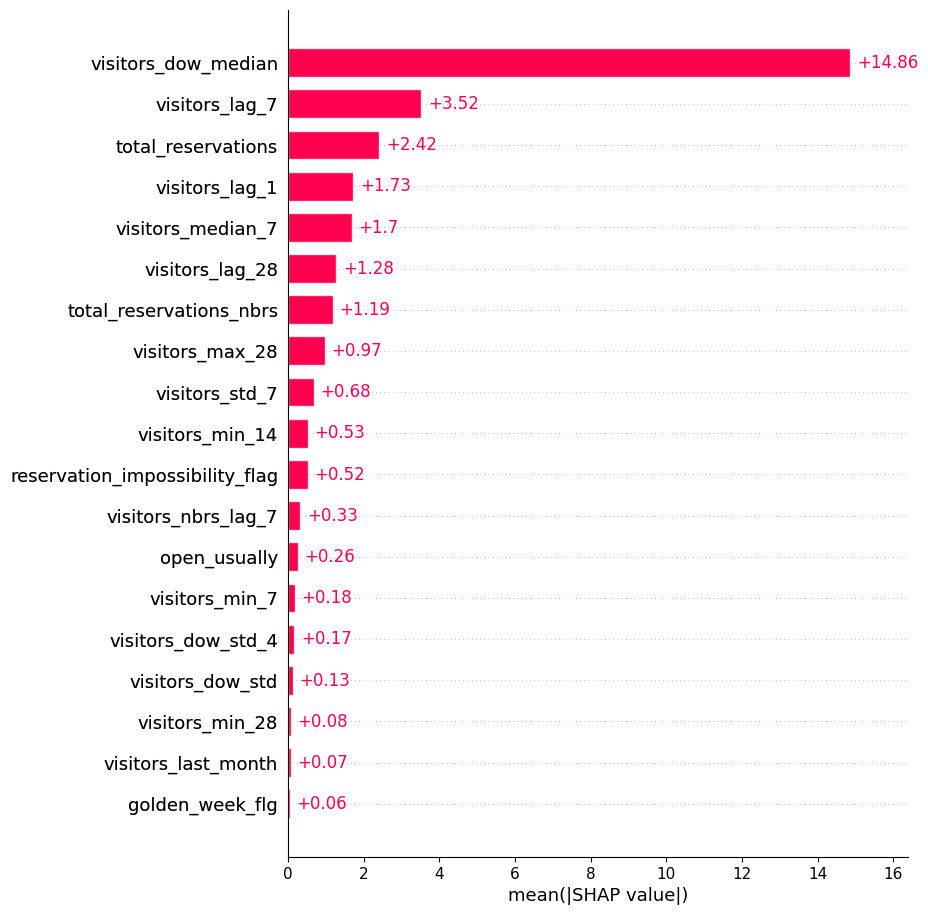

In [32]:
shap_many_visitors = explainer(X_pred_90q)
shap.plots.bar(shap_many_visitors, max_display=24)

In [53]:
X_q90 = X_y[X_y["predicted"] > X_y[VISITORS_COL] + 5]
X_less_q90 = X_y

In [54]:
get_features_difference(X_q90, X_less_q90, 7, numeric_cols)

,air_store_id,visit_date,visitors,visitors_prev,predicted,golden_week_flg_diff,open_usually_diff,reservation_impossibility_flag_diff,total_reservations_diff,total_reservations_nbrs_diff,...,visitors_min_28_diff,visitors_lag_1_diff,visitors_lag_7_diff,visitors_lag_28_diff,visitors_nbrs_lag_7_diff,visitors_last_month_diff,visitors_dow_median_diff,visitors_dow_std_diff,visitors_dow_std_4_diff,predicted_diff
33543,air_dfad598ff642dab7,2016-11-20,3,38,27.973922,0.0,0.0,0.0,0.0,6.461777,...,0.0,-24.0,13.0,4.0,0.063462,0.0,0.0,-0.042937,4.692395,1.016912
13024,air_55c3627912b9c849,2016-08-02,4,17,9.170577,0.0,0.0,0.0,0.0,-8.933005,...,0.0,1.0,15.0,5.0,0.783797,7.0,0.0,0.106887,1.698937,0.050979
46478,air_fbadf737162a5ce3,2017-01-16,9,25,19.882948,0.0,0.0,0.0,0.0,-9.294395,...,0.0,-8.0,25.0,-7.0,7.670078,-1.0,0.0,-0.077282,0.306691,-0.656807
17461,air_77dfc83450cbc89c,2016-08-27,18,44,40.986881,0.0,0.0,0.0,0.0,-0.009236,...,0.0,10.0,10.0,8.0,2.625903,7.0,0.5,-0.179313,0.691468,3.513030
23689,air_d34c0861a2be94cb,2016-09-29,19,36,44.022834,0.0,0.0,0.0,0.0,2.668231,...,0.0,2.0,-26.0,-17.0,1.815101,8.0,0.0,0.078648,2.549512,-0.666913
20851,air_a85f8c0bfd61889f,2016-09-15,0,7,8.058361,0.0,0.0,0.0,0.0,-1.626959,...,0.0,-6.0,-3.0,5.0,4.008994,-1.0,0.0,-0.424239,0.021398,-0.713874
47942,air_36429b5ca4407b3e,2017-01-24,12,1,17.122814,0.0,0.0,0.0,8.0,9.658371,...,0.0,-4.0,1.0,4.0,-2.142857,-15.0,0.0,0.165915,0.945480,5.642385
35215,air_500641aca4cf673c,2016-11-29,0,0,6.661041,0.0,0.0,0.0,0.0,-3.233393,...,0.0,0.0,0.0,0.0,5.398707,7.0,-0.5,0.055274,0.000000,-0.286876
43942,air_464a62de0d57be1e,2017-01-05,10,41,19.619008,0.0,0.0,0.0,0.0,-14.706825,...,-14.0,-13.0,-1.0,4.0,-5.600550,-2.0,0.0,1.204348,1.037513,-13.126302
4724,air_e88bbe2ede3467aa,2016-04-17,22,39,30.048216,0.0,0.0,0.0,0.0,-4.799154,...,13.0,12.0,5.0,51.0,4.571429,-14.0,1.5,-0.206698,-5.837147,2.455317


## Testing on future data

In [3]:
model_shap = joblib.load(MODEL_PATH)

In [17]:
test_features = pd.read_csv(PROCESSED_DATA_DIR / "test_features.csv")
test_features = prepare_features(test_features)
test_features = test_features.reset_index(drop=True)

In [31]:
test_labels, temp_features = recursive_predict(
    model_shap,
    test_features,
    X,
    y,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively: 100%|██████████| 39/39 [00:33<00:00,  1.18it/s]


In [20]:
labels_format = get_format(test_features, test_labels)
labels_format.to_csv(PROCESSED_DATA_DIR / "test_labels.csv", index=False)

## Saving model

In [59]:
kaggle_score = -1

if MLFLOW_WORK:
    with mlflow.start_run(run_name=MODEL_NAME):
        best_cv_result = cv_results.sort_values("rank_test_score").iloc[0].to_dict()
        mlflow.log_dict(
            best_cv_result,
            artifact_file="best_cv_result.json"
        )

        mlflow.log_param("cv_splits", CV_SPLITS)
        mlflow.log_param("test_size", TEST_SIZE)
        mlflow.log_param("feature_selection_validation_size", FS_VALID_SIZE)
        mlflow.log_param("first_iteration_n_trials", FIRST_ITER_TRIALS)
        mlflow.log_param("second_iteration_n_trials", SECOND_ITER_TRIALS)
        mlflow.log_param("objective_function", OBJECTIVE_FUNCTION)
        mlflow.log_params(best_cv_result["params"])

        mlflow.log_metric("test_rmsle", test_rmsle)
        mlflow.log_metric("kaggle_rmsle", kaggle_score)
        mlflow.log_metric("cv_mean_test_score", best_cv_result["mean_test_score"])
        mlflow.log_metric("cv_std_test_score", best_cv_result["std_test_score"])

        mlflow.sklearn.log_model(
            sk_model=model_shap,
            name=MODEL_NAME
        )

        mlflow.set_tags({
            "feature_ranking_method": "None",
            "feature_selection_strategy": "None",
            "training_window_size": 39,
            "max_depth": "enabled",
            "fill_gaps": "no filling; set reservation_impossibility=1",
        })

2026/05/15 18:18:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/15 18:18:31 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
